In [2]:
from datascience import *
import numpy as np
%matplotlib inline
import matplotlib.pyplot as plots
plots.style.use('fivethirtyeight')
import warnings
warnings.simplefilter(action="ignore", category=FutureWarning)

from urllib.request import urlopen 
import re
def read_url(url): 
    return re.sub('\\s+', ' ', urlopen(url).read().decode())

In [3]:
huck_finn_url = 'https://www.inferentialthinking.com/data/huck_finn.txt'
huck_finn_text = read_url(huck_finn_url)
huck_finn_chapters = huck_finn_text.split('CHAPTER ')[44:]

In [4]:
little_women_url = 'https://www.inferentialthinking.com/data/little_women.txt'
little_women_text = read_url(little_women_url)
little_women_chapters = little_women_text.split('CHAPTER ')[1:]


In [5]:
huck_finn_table = Table().with_column('Chapters',huck_finn_chapters)
# huck_finn_table

In [6]:
np.char.count(huck_finn_chapters, 'Tom')

array([ 6, 24,  5,  0,  0,  0,  2,  2,  0,  0,  2,  3,  1,  0,  0,  0,  3,
        5,  0,  0,  0,  0,  0,  0,  0,  0,  0,  1,  0,  0,  1,  4, 19, 15,
       14, 18,  9, 32, 11, 11,  8, 30,  6])

In [7]:
np.char.count(huck_finn_chapters, 'Jim')
# Tom shows up in later chapters. 
# Jim is 

array([ 0, 16,  0,  8,  0,  0,  0, 22, 11, 19,  4, 20,  9,  6, 16, 28,  0,
       10, 13, 18,  1,  0,  9,  5,  0,  0,  0,  1,  3,  5, 17,  0,  5, 17,
       18, 23,  4, 27, 10, 13,  0, 12,  6])

In [8]:
tom_count = np.char.count(huck_finn_chapters, 'Tom')
jim_count = np.char.count(huck_finn_chapters, 'Jim')
huck_count = np.char.count(huck_finn_chapters, 'Huck')
counts = Table().with_columns('Tom',tom_count, 'Jim',jim_count, 'Huck',huck_count)
#counts

In [9]:
tom_cum = np.cumsum(tom_count)
jim_cum = np.cumsum(jim_count)
huck_cum = np.cumsum(huck_count)
cum_counts = Table().with_columns('Chapter',np.arange(1,44),'Tom',tom_cum, 'Jim',jim_cum, 'Huck',huck_cum)

# cum_counts.plot('Chapter')
# plots.title('Cumulative Number of Times Each Name Appears', y=1.08)
# 

In [10]:
I_count = np.char.count(huck_finn_chapters,'I')
I_cum = np.cumsum(I_count)
cum_counts = cum_counts.with_column('I',I_cum)
# cum_counts.plot('Chapter')

In [11]:
little_women_table = Table().with_columns('Chapters', little_women_chapters)
# little_women_table

In [12]:
amy_count = np.char.count(little_women_chapters,'Amy')
beth_count = np.char.count(little_women_chapters,'Beth')
jo_count = np.char.count(little_women_chapters,'Jo')
laurie_count = np.char.count(little_women_chapters,'Laurie')
meg_count = np.char.count(little_women_chapters,'Meg')

amy_cum = np.cumsum(amy_count)
beth_cum = np.cumsum(beth_count)
jo_cum = np.cumsum(jo_count)
laurie_cum = np.cumsum(laurie_count)
meg_cum = np.cumsum(meg_count)

cum_counts = Table().with_columns('Chapter',np.arange(1,48),'Amy',amy_cum, 'Beth',beth_cum, 'Jo',jo_cum, 'Laurie',laurie_cum, 'Meg',meg_cum)
# cum_counts.plot('Chapter')
# Who is the main character?
# Who dies? Which chapter? 
# Who does Laurie marry? What chapter?

In [13]:
chars_periods_huck_finn = Table().with_columns([
        'Huck Finn Chapter Length', [len(s) for s in huck_finn_chapters],
        'Number of Periods', np.char.count(huck_finn_chapters, '.')
    ])
chars_periods_little_women = Table().with_columns([
        'Little Women Chapter Length', [len(s) for s in little_women_chapters],
        'Number of Periods', np.char.count(little_women_chapters, '.')
    ])

In [14]:
# chars_periods_huck_finn

In [15]:
# chars_periods_little_women

Little Women Chapter Length,Number of Periods
21759,189
22148,188
20558,231
25526,195
23395,255
14622,140
14431,131
22476,214
33767,337
18508,185


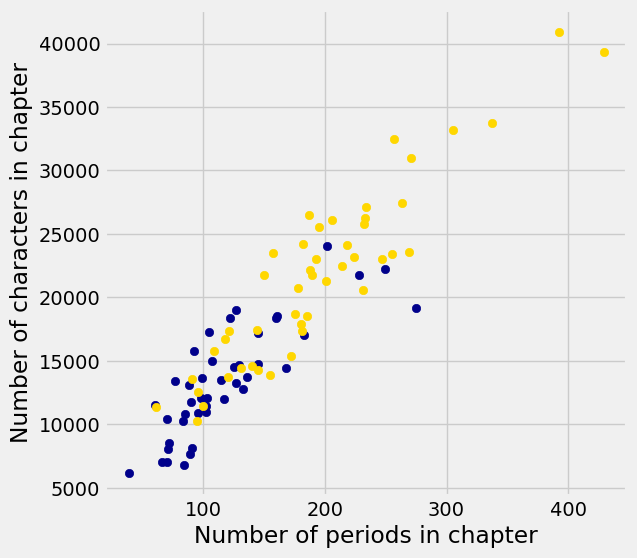

In [16]:
plots.figure(figsize=(6, 6))
plots.scatter(chars_periods_huck_finn.column(1), 
              chars_periods_huck_finn.column(0), 
              color='darkblue')
plots.scatter(chars_periods_little_women.column(1), 
              chars_periods_little_women.column(0), 
              color='gold')
plots.xlabel('Number of periods in chapter')
plots.ylabel('Number of characters in chapter');